In [1]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import timesfm

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.timesfm_wrapper import TimesFMForecaster
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)].


In [3]:
DATA_DIR

'../data'

In [4]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [5]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [6]:
hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
checkpoint = timesfm.TimesFmCheckpoint(version = "torch", huggingface_repo_id="google/timesfm-1.0-200m-pytorch")
forecaster = timesfm.TimesFm(hparams = hparams, checkpoint=checkpoint)

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


In [7]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()
    forecaster = TimesFMForecaster(hparams = hparams)
    
    for symbol in crypto_symbols:
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)

        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])

        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            # if scaler is not None:
            #     train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            # if scaler is not None:
            #     train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            # if scaler is not None:
            #     test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
            test_forecast_df.columns = ["Forecasted_Close"]
            # if scaler is not None:
            #     test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            # if scaler is not None:
            #     test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)
        print(f"Data written to {output_file_path}")
        plot_actual_vs_forecast_for_a_symbol(symbol, combined_data)
        eval_metrics = evaluate_forecast_one_symbol(combined_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")

    
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")

efeb3c31-1e67-4fbc-957d-39f3fc9e4ad0


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 20.99705195426941 seconds
Data written to ../data\outputs\BTC-USD_timesfm_30_efeb3c31-1e67-4fbc-957d-39f3fc9e4ad0_forecasts.csv


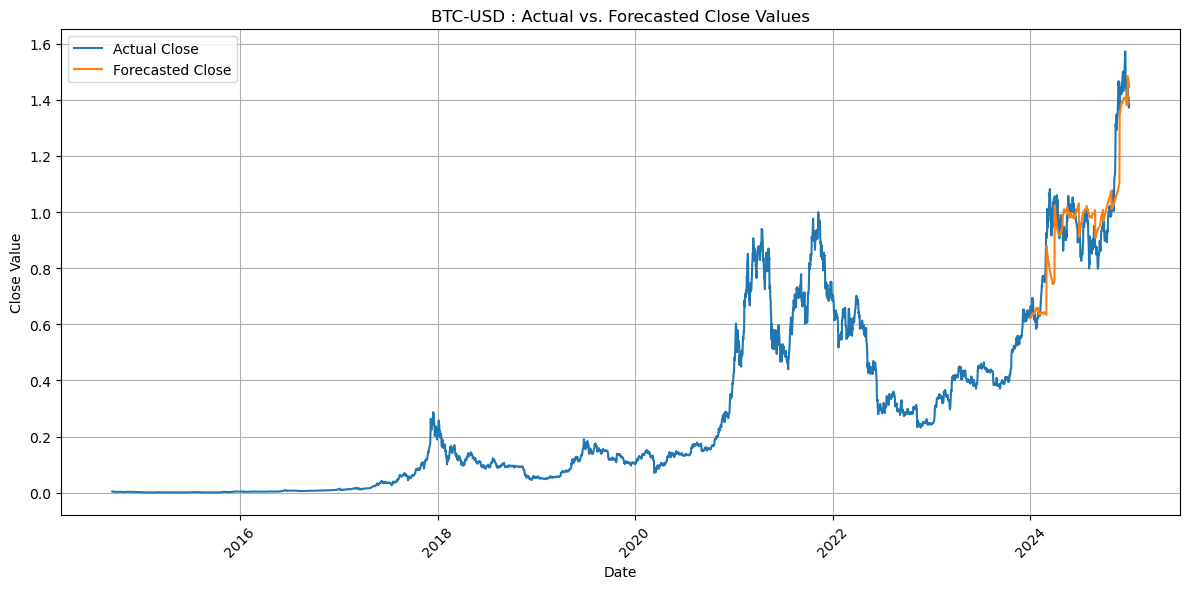

MAPE: 8.681056682103533
ME: 0.017535819006107674
MAE: 0.08552356163840878
MPE: 0.9933489433729457
RMSE: 0.11460719217402335
R: 0.8564552225697123
Scalar Product: 0.0027323555737661445
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857
Execution time for forecast_crypto_prices(): 40.326517820358276 seconds
Data written to ../data\outputs\BNB-USD_timesfm_30_efeb3c31-1e67-4fbc-957d-39f3fc9e4ad0_forecasts.csv


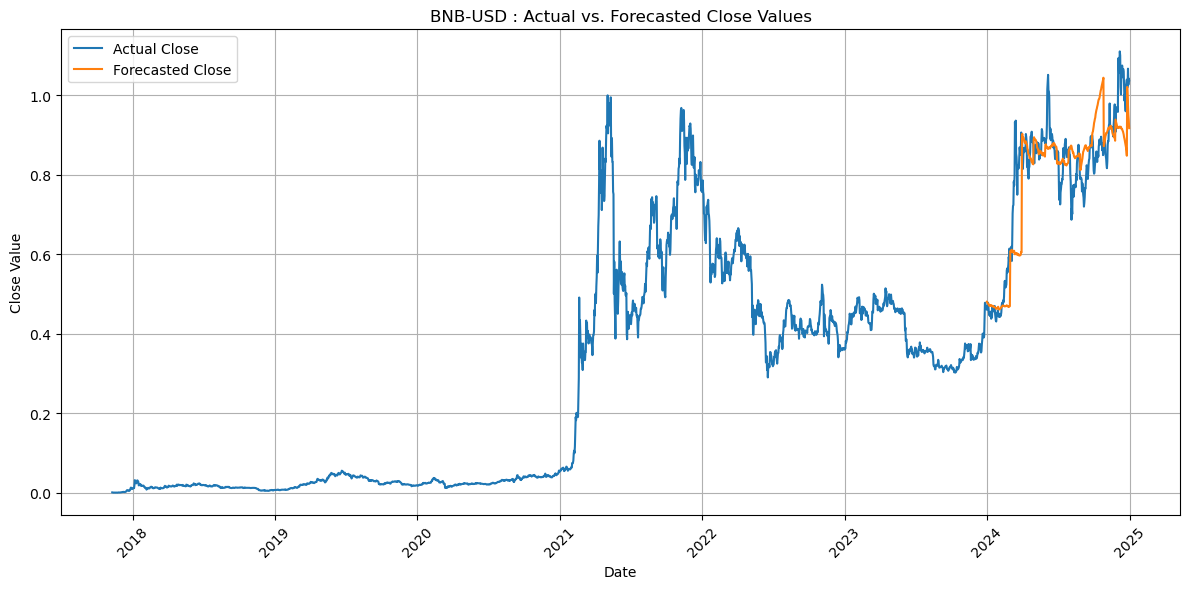

MAPE: 8.034259807869965
ME: 0.011272938872503763
MAE: 0.06606559533275055
MPE: 0.9098012811069389
RMSE: 0.09346720103733622
R: 0.8439533376940682
Scalar Product: -0.007385083742510117
Return Score: 0.473972602739726
Long Return: 0.4607329842931937
Short Return: 0.4885057471264368
Mean Directional Accuracy: 0.473972602739726
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4885057471264368
Execution time for forecast_crypto_prices(): 59.42629551887512 seconds
Data written to ../data\outputs\ETH-USD_timesfm_30_efeb3c31-1e67-4fbc-957d-39f3fc9e4ad0_forecasts.csv


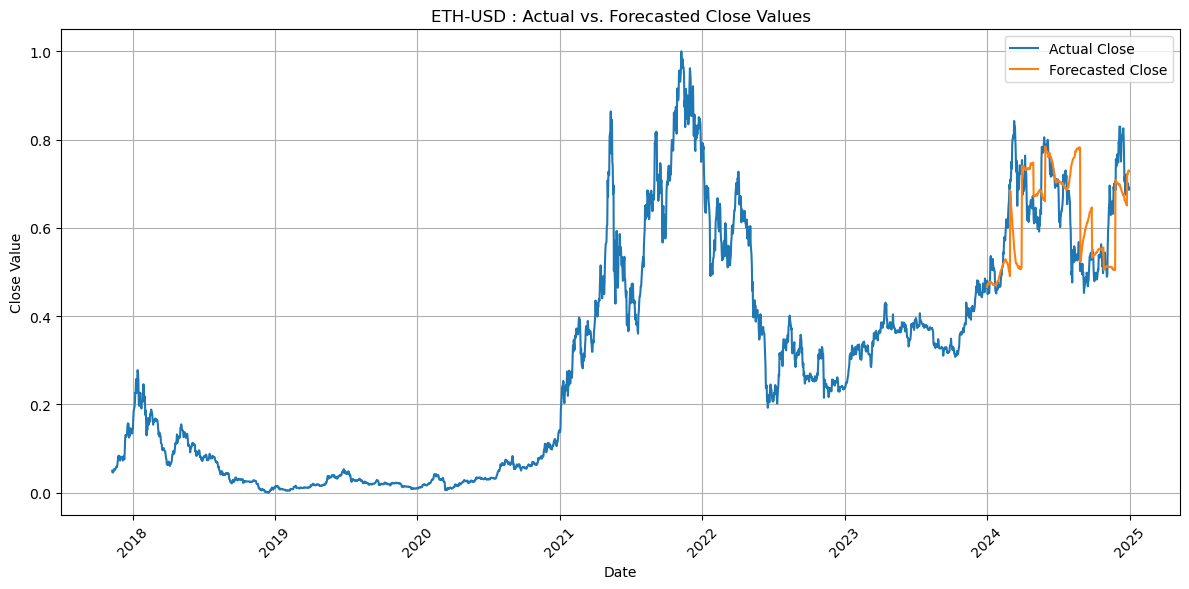

MAPE: 13.112340017696555
ME: 0.0003409074370305734
MAE: 0.08150907070253696
MPE: -1.6090463414306935
RMSE: 0.10943238989392631
R: 0.4552887330387021
Scalar Product: -0.0011945549136492817
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193
Execution time for forecast_crypto_prices(): 78.49487829208374 seconds
Data written to ../data\outputs\SOL-USD_timesfm_30_efeb3c31-1e67-4fbc-957d-39f3fc9e4ad0_forecasts.csv


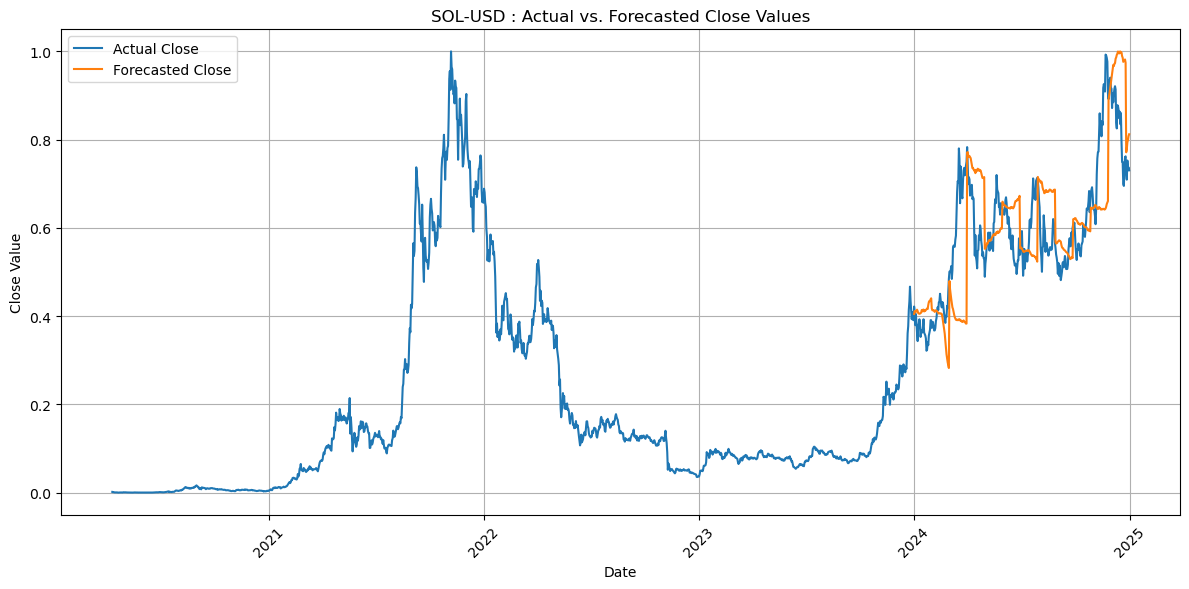

MAPE: 15.029545788402546
ME: -0.0018581589060048527
MAE: 0.09290596133588068
MPE: -1.8219870566244818
RMSE: 0.12647696614809278
R: 0.6547066326253929
Scalar Product: 0.028615254753751044
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


2200

In [8]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 'm')
gc.collect()

240db86b-74ac-4a60-a52e-a28c3c281061


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 77.12867999076843 seconds
Data written to ../data\outputs\BTC-USD_timesfm_7_240db86b-74ac-4a60-a52e-a28c3c281061_forecasts.csv


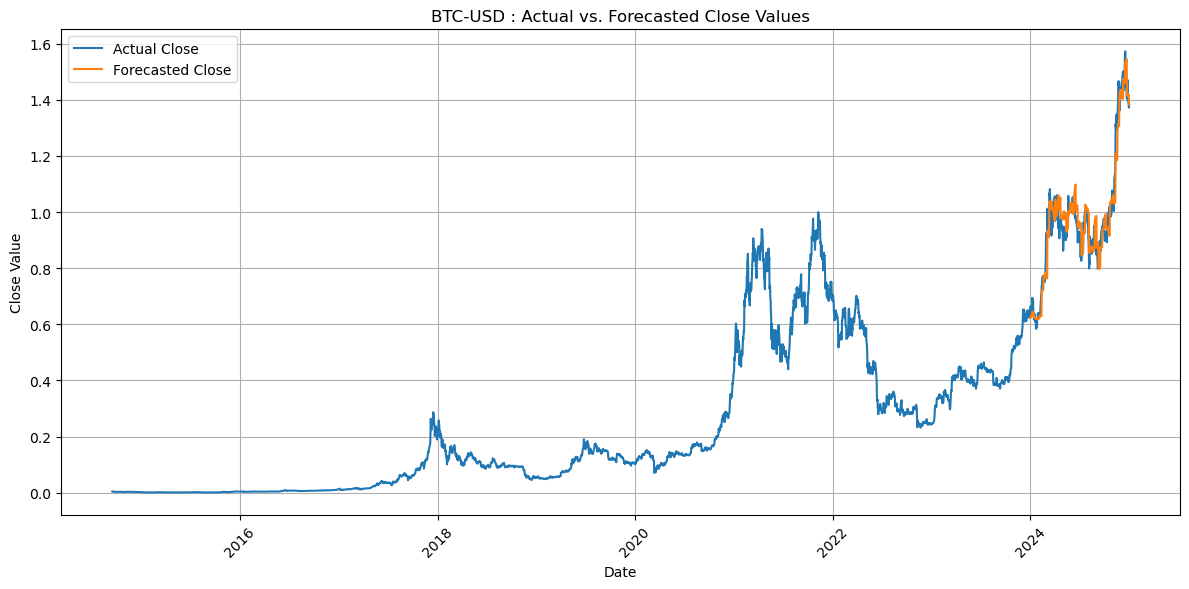

MAPE: 5.023139628439389
ME: 0.0011228534191796012
MAE: 0.04889873797558012
MPE: -0.09448578765118648
RMSE: 0.061977488938588975
R: 0.9588768743224154
Scalar Product: 0.03867816152368618
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714
Execution time for forecast_crypto_prices(): 151.38757157325745 seconds
Data written to ../data\outputs\BNB-USD_timesfm_7_240db86b-74ac-4a60-a52e-a28c3c281061_forecasts.csv


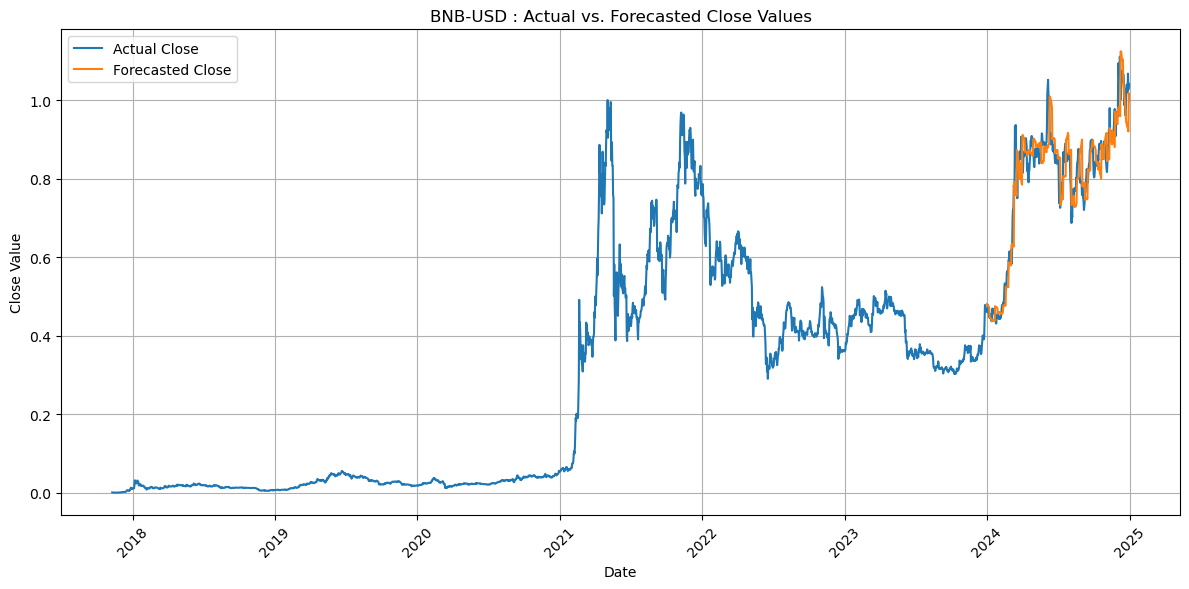

MAPE: 5.182146352572074
ME: 0.005836553201206053
MAE: 0.04255310340728764
MPE: 0.5254018558388839
RMSE: 0.05536337287020861
R: 0.9438947248510563
Scalar Product: -0.02825243849045163
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896
Execution time for forecast_crypto_prices(): 226.73910403251648 seconds
Data written to ../data\outputs\ETH-USD_timesfm_7_240db86b-74ac-4a60-a52e-a28c3c281061_forecasts.csv


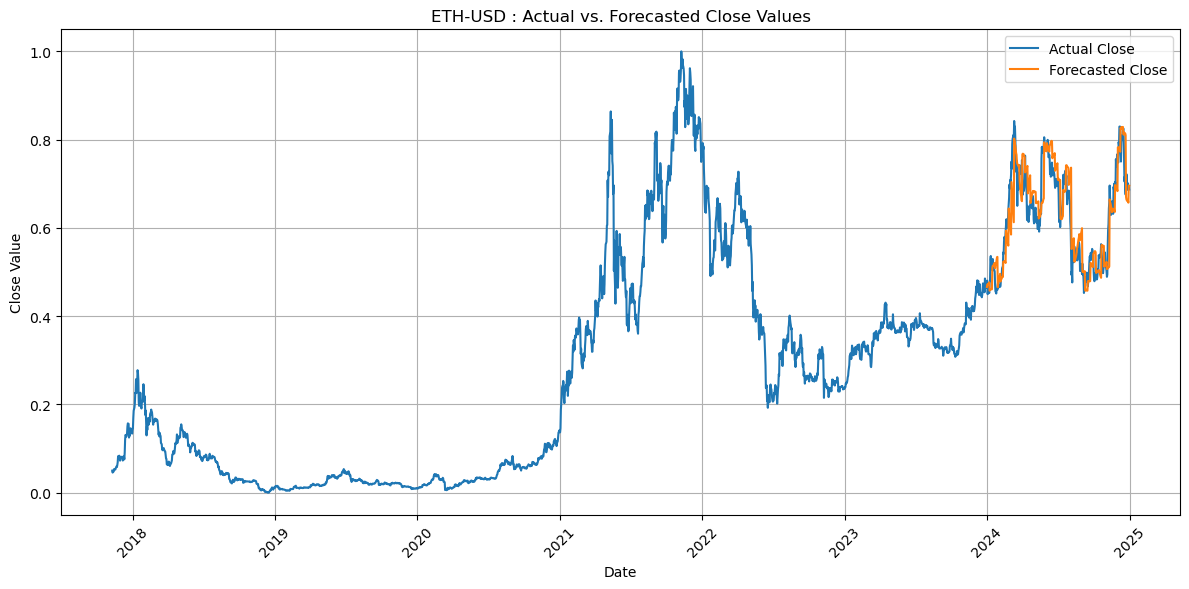

MAPE: 6.619799494959329
ME: -0.0036301044752058698
MAE: 0.04152936758854139
MPE: -0.9011316968949344
RMSE: 0.05397906577175431
R: 0.8770788670270712
Scalar Product: 0.01586193068192805
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873
Execution time for forecast_crypto_prices(): 302.2882730960846 seconds
Data written to ../data\outputs\SOL-USD_timesfm_7_240db86b-74ac-4a60-a52e-a28c3c281061_forecasts.csv


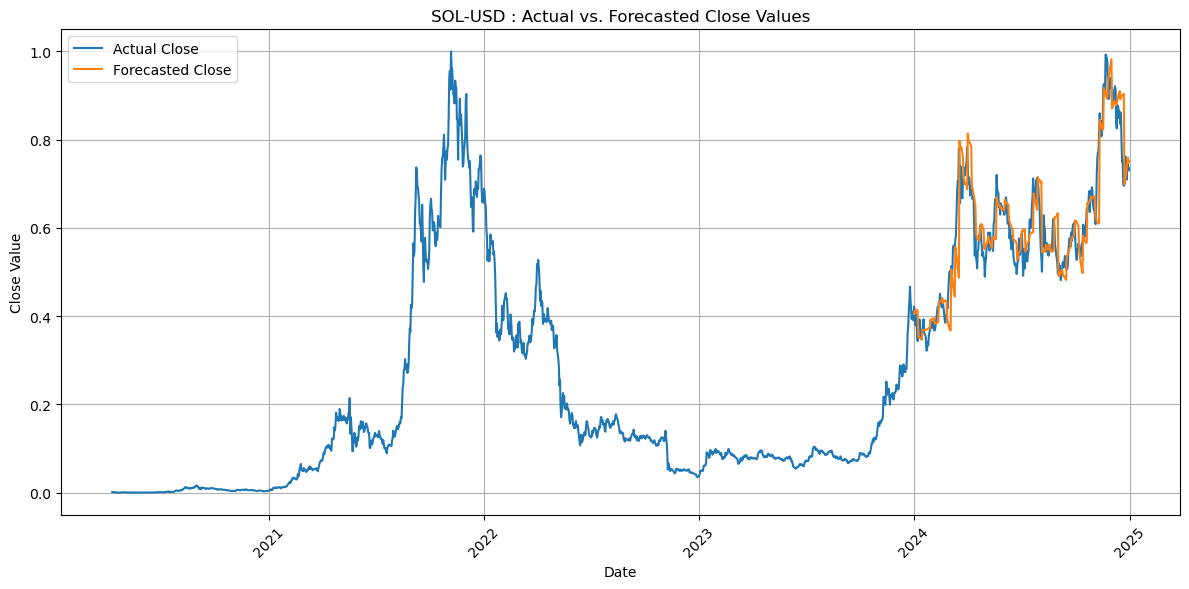

MAPE: 6.754750275282214
ME: -0.0027739870415004813
MAE: 0.04043345801985466
MPE: -0.8014932987569825
RMSE: 0.05848057622901408
R: 0.9202504565569938
Scalar Product: 0.005677914503242984
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


17155

In [9]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = 'm')
gc.collect()

731c13ed-976f-4c12-b86f-d2b0100a1c4c


Fetching 3 files: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 738.78it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 516.9622967243195 seconds
Data written to ../data\outputs\BTC-USD_timesfm_1_731c13ed-976f-4c12-b86f-d2b0100a1c4c_forecasts.csv


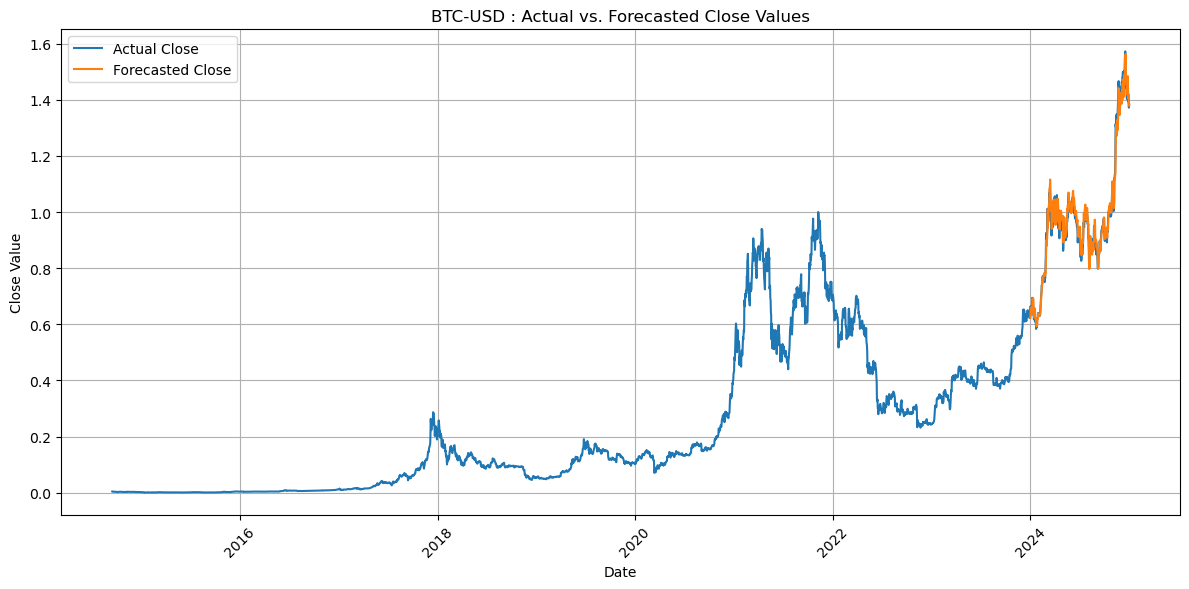

MAPE: 2.543496484933773
ME: -0.0045254462253739944
MAE: 0.025049794473590917
MPE: -0.624297302378782
RMSE: 0.032818547323671336
R: 0.9889288771828395
Scalar Product: -0.004955625813912869
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713
Execution time for forecast_crypto_prices(): 1033.5949301719666 seconds
Data written to ../data\outputs\BNB-USD_timesfm_1_731c13ed-976f-4c12-b86f-d2b0100a1c4c_forecasts.csv


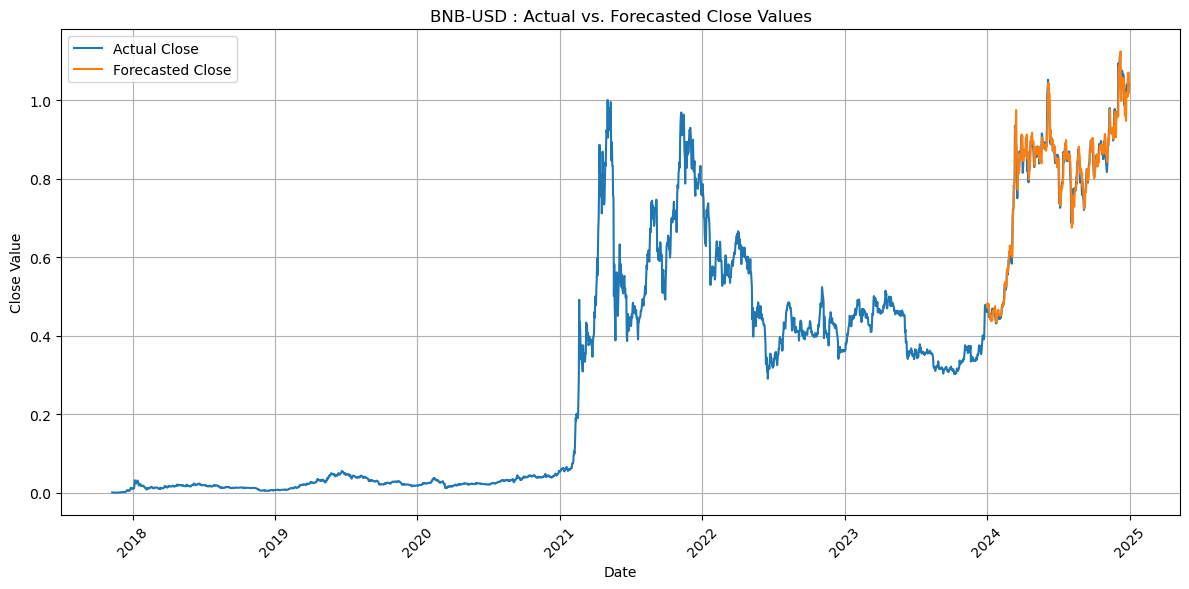

MAPE: 2.408788209639282
ME: -0.0012411802301514503
MAE: 0.019426929570783215
MPE: -0.26608404543893865
RMSE: 0.027744957547675905
R: 0.9857736594776473
Scalar Product: -0.006198939666952058
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 1547.232768535614 seconds
Data written to ../data\outputs\ETH-USD_timesfm_1_731c13ed-976f-4c12-b86f-d2b0100a1c4c_forecasts.csv


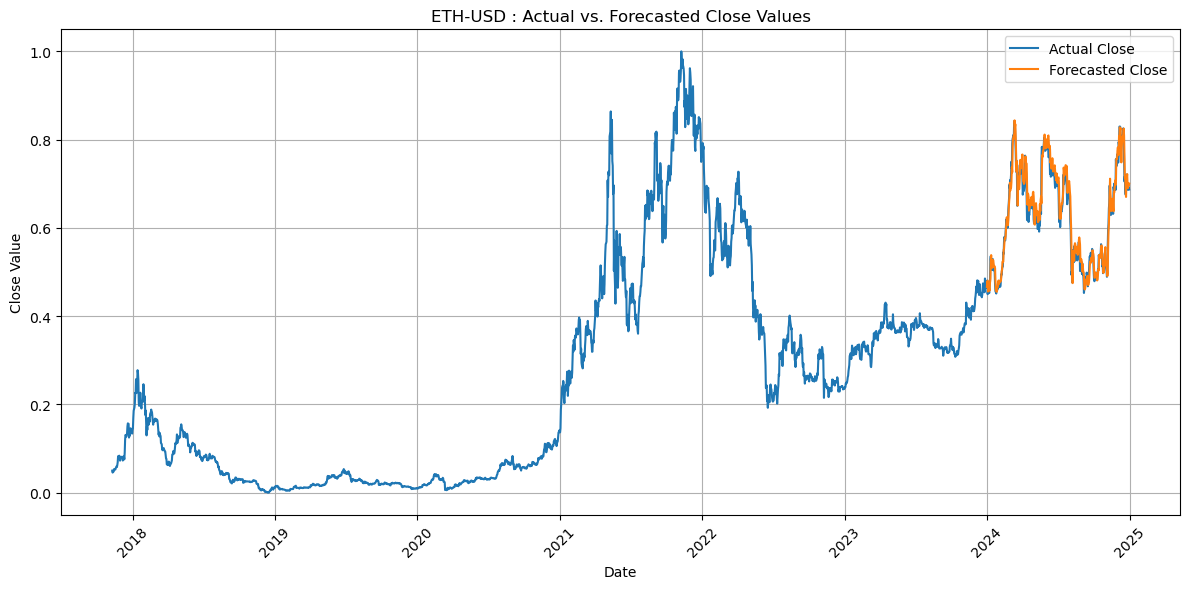

MAPE: 3.005371487364692
ME: -0.006230762610541824
MAE: 0.018842534929575203
MPE: -1.029751252367043
RMSE: 0.025119199566581634
R: 0.9751251339120264
Scalar Product: -0.0022168833277935677
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 2054.1287655830383 seconds
Data written to ../data\outputs\SOL-USD_timesfm_1_731c13ed-976f-4c12-b86f-d2b0100a1c4c_forecasts.csv


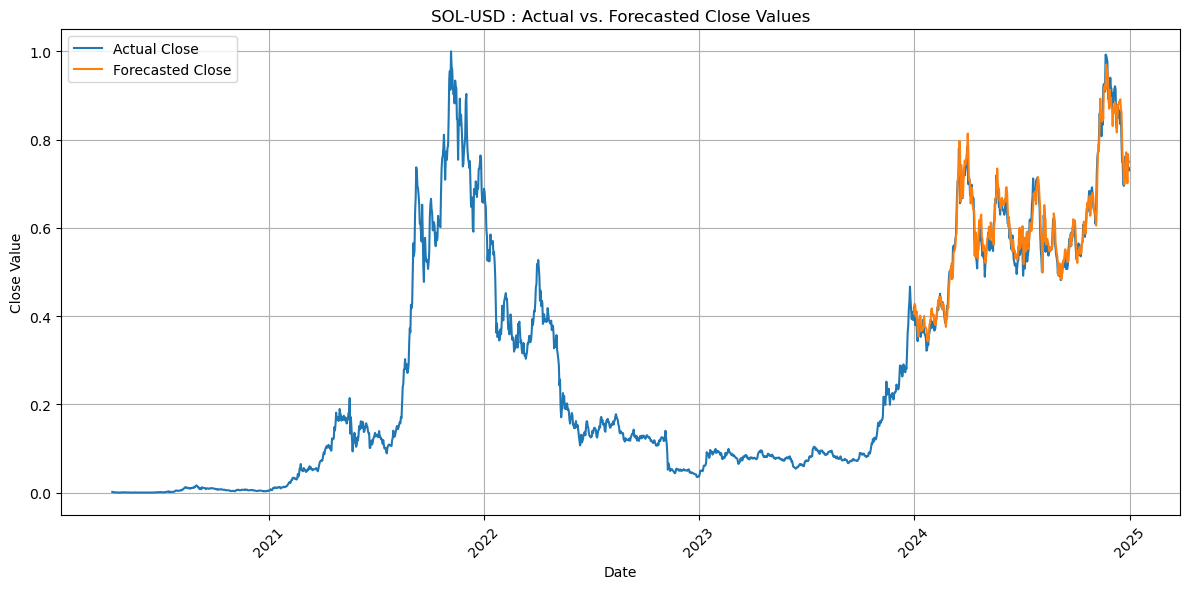

MAPE: 4.008410692553838
ME: -0.006018914387881163
MAE: 0.0236015580143322
MPE: -1.349168583278295
RMSE: 0.03019995437031205
R: 0.9787222401777902
Scalar Product: -0.014694631213840428
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


17164

In [10]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = 'm')
gc.collect()